# **Project 1 - Kenya Transmission Infrastructure Data Quality and Exploratory Analysis**

Project Objective:

Assess the quality, structure and characteristics of a Kenyan transmission-station dataset and develop a reproducible data-cleaning and exploratory-analysis pipeline.

**Dataset structure**

- How many stations are represented?
- Which counties?
- Which regional control areas?
- Which owners?
- Which voltage classes?
- Which sources?


**Data quality**

Calculate:
- missing percentage per variable
- missing percentage per station
- duplicate station names
- inconsistent categorical values
- suspicious dates
- inconsistent voltage notation
- records with incomplete metadata.

**EDA: To produce visualizations such as:**

- stations by county
- stations by owner
- stations by voltage level
- stations by region
- manned vs unmanned
- remote monitoring availability
- communication availability
- access type
- data completeness by source.

## Skills demonstrated
Python (pandas, NumPy, regex, datetime), data cleaning and reconciliation, missing-data analysis, feature engineering, visualisation (matplotlib, seaborn), documentation and reproducibility.

# 1. Import Libraries

In [ ]:
# Fixing the path for the json file
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data/RAW/transmission_stations.json"
INTERIM = ROOT / "data/INTERIM/transmission_stations_flattened.csv"
PROCESSED = ROOT / "data/PROCESSED/transmission_stations_cleaned.csv"

In [4]:
import json
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


# 2. Load Data and Convert JSON into CSV

In [5]:

# Load GeoJSON
with open(RAW, "r", encoding="utf-8") as f:
    data = json.load(f)

records = []

for feature in data["features"]:
    properties = feature["properties"].copy()

    # Extract coordinates
    coordinates = feature["geometry"]["coordinates"]
    properties["x"] = coordinates[0]
    properties["y"] = coordinates[1]

    records.append(properties)

# Create DataFrame
df = pd.DataFrame(records)

# Save flattened CSV (interim file, raw JSON is left untouched)
INTERIM.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(INTERIM, index=False)

# Inspect
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

   FID  OBJECTID                RCC1        County2  \
0    0         1  Juja-Nairobi South  Nairobi South   
1    1         2    Kiganjo Mt kenya           Embu   
2    2         3  Juja-Nairobi South       Machakos   
3    3         4  Juja-Nairobi South  Nairobi South   
4    4         5  Juja-Nairobi North  Nairobi North   

                           Branch3  \
0        Komarock - Kayole - Umoja   
1                          Kamburu   
2                            Kivaa   
3       Industrial Area - Embakasi   
4  Dandora - Kariobangi - Githurai   

                                        Name_IMS11           FDB_Last18  \
0                          DANDORA ( 220 / 132 KV)  25/03/2014 13:39:36   
1  KAMBURU 132 KV SUBSTATION ( 11,132 / 33,132 KV)  04/07/2014 10:19:05   
2             KINDARUMA SUB STATION ( 11 / 132 KV)  25/03/2014 13:41:23   
3                         EMBAKASI  ( 220 / 66 KV)  25/02/2016 08:33:42   
4              JUJA  SUBSTATION ( 132 / 132,66 KV)  17/06/2014 18

In [6]:
df.head(5)

,FID,OBJECTID,RCC1,County2,Branch3,Name_IMS11,FDB_Last18,Ownershi23,Street40,Type_Acc42,Manned50,VHF_Radi55,Earthing56,Remote_T57,Programm58,Ripple_C59,Source,x,y
0,0,1,Juja-Nairobi South,Nairobi South,Komarock - Kayole - Umoja,DANDORA ( 220 / 132 KV),25/03/2014 13:39:36,KPLC,KOMOROCK RD.,MURRAM,NO,,YES,YES,YES,YES,KPLC FDB,268017.834207,9.860476e+06
1,1,2,Kiganjo Mt kenya,Embu,Kamburu,"KAMBURU 132 KV SUBSTATION ( 11,132 / 33,132 KV)",04/07/2014 10:19:05,KPLC & KENGEN,KANGONDE - EMBU ROAD,TARMAC,YES,YES,YES,YES,YES,NO,KPLC FDB,353715.479012,9.910924e+06
2,2,3,Juja-Nairobi South,Machakos,Kivaa,KINDARUMA SUB STATION ( 11 / 132 KV),25/03/2014 13:41:23,KPLC & KENGEN,KINDARUMA ROAD,TARMAC,YES,YES,YES,YES,NO,NO,KPLC FDB,367936.260806,9.910406e+06
3,3,4,Juja-Nairobi South,Nairobi South,Industrial Area - Embakasi,EMBAKASI ( 220 / 66 KV),25/02/2016 08:33:42,KPLC,OFF MOMBASA RD.,TARMAC,YES,YES,YES,NO,NO,YES,KPLC FDB,263416.240885,9.851775e+06
4,4,5,Juja-Nairobi North,Nairobi North,Dandora - Kariobangi - Githurai,"JUJA SUBSTATION ( 132 / 132,66 KV)",17/06/2014 18:46:22,KPLC,JUJA RD.,TARMAC,YES,NO,YES,YES,YES,YES,KPLC FDB,266944.383619,9.861229e+06


# 3. Dataset Overview

Dataset Profile

In [7]:
# a basic dataset profile
print("Number of rows", df.shape[0])
print("Number of columns", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows 83
Number of columns 19

Column names:
['FID', 'OBJECTID', 'RCC1', 'County2', 'Branch3', 'Name_IMS11', 'FDB_Last18', 'Ownershi23', 'Street40', 'Type_Acc42', 'Manned50', 'VHF_Radi55', 'Earthing56', 'Remote_T57', 'Programm58', 'Ripple_C59', 'Source', 'x', 'y']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   FID         83 non-null     int64  
 1   OBJECTID    83 non-null     int64  
 2   RCC1        83 non-null     str    
 3   County2     83 non-null     str    
 4   Branch3     83 non-null     str    
 5   Name_IMS11  83 non-null     str    
 6   FDB_Last18  83 non-null     str    
 7   Ownershi23  83 non-null     str    
 8   Street40    83 non-null     str    
 9   Type_Acc42  83 non-null     str    
 10  Manned50    83 non-null     str    
 11  VHF_Radi55  83 non-null     str    
 12  Earthing56  83 non-null     str  

Descriptive Statistics

In [8]:
df.describe()

,FID,OBJECTID,x,y
count,83.000000,83.000000,83.000000,8.300000e+01
mean,41.000000,42.000000,277247.803125,9.890747e+06
std,24.103942,24.103942,189324.618227,1.603421e+05
min,0.000000,1.000000,-43819.108149,9.522406e+06
25%,20.500000,21.500000,94102.900544,9.820063e+06
50%,41.000000,42.000000,266944.383619,9.910924e+06
75%,61.500000,62.500000,372130.839046,9.993232e+06
max,82.000000,83.000000,698229.520879,1.027542e+07


In [9]:
df.describe(include = "object")

/var/folders/1v/3b8_4jr94g7_pkjyjk4j95qh0000gn/T/ipykernel_4980/3591357663.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = "object")


,RCC1,County2,Branch3,Name_IMS11,FDB_Last18,Ownershi23,Street40,Type_Acc42,Manned50,VHF_Radi55,Earthing56,Remote_T57,Programm58,Ripple_C59,Source
count,83,83,83,83,83,83,83,83,83,83,83,83,83,83,83
unique,11,28,36,57,51,7,48,3,3,4,2,3,3,3,2
top,,,,,,KPLC,,,YES,,YES,YES,,,KPLC FDB
freq,27,27,27,27,27,46,30,38,39,51,56,38,42,39,56


 # 4. Data types

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   FID         83 non-null     int64  
 1   OBJECTID    83 non-null     int64  
 2   RCC1        83 non-null     str    
 3   County2     83 non-null     str    
 4   Branch3     83 non-null     str    
 5   Name_IMS11  83 non-null     str    
 6   FDB_Last18  83 non-null     str    
 7   Ownershi23  83 non-null     str    
 8   Street40    83 non-null     str    
 9   Type_Acc42  83 non-null     str    
 10  Manned50    83 non-null     str    
 11  VHF_Radi55  83 non-null     str    
 12  Earthing56  83 non-null     str    
 13  Remote_T57  83 non-null     str    
 14  Programm58  83 non-null     str    
 15  Ripple_C59  83 non-null     str    
 16  Source      83 non-null     str    
 17  x           83 non-null     float64
 18  y           83 non-null     float64
dtypes: float64(2), int64(2), str(15)
memory us

# 5. Missing Values

In [11]:
#check for missing values in the columns
df.isnull().sum()

FID           0
OBJECTID      0
RCC1          0
County2       0
Branch3       0
Name_IMS11    0
FDB_Last18    0
Ownershi23    0
Street40      0
Type_Acc42    0
Manned50      0
VHF_Radi55    0
Earthing56    0
Remote_T57    0
Programm58    0
Ripple_C59    0
Source        0
x             0
y             0
dtype: int64

No missing value shown. Check for blank strings

In [12]:
missing_percentage = (df.isnull().sum()/ len(df)) * 100
missing_percentage.sort_values(ascending = False)

FID           0.0
Manned50      0.0
x             0.0
Source        0.0
Ripple_C59    0.0
Programm58    0.0
Remote_T57    0.0
Earthing56    0.0
VHF_Radi55    0.0
Type_Acc42    0.0
OBJECTID      0.0
Street40      0.0
Ownershi23    0.0
FDB_Last18    0.0
Name_IMS11    0.0
Branch3       0.0
County2       0.0
RCC1          0.0
y             0.0
dtype: float64

In [13]:
# Detect Blank Strings

blank_count = (df == " ").sum()
blank_count.sort_values(ascending = False)

VHF_Radi55    51
Programm58    42
Ripple_C59    39
Type_Acc42    38
Remote_T57    38
Street40      30
RCC1          27
County2       27
Branch3       27
Name_IMS11    27
FDB_Last18    27
Ownershi23    27
Manned50      27
Earthing56    27
Source         0
x              0
FID            0
OBJECTID       0
y              0
dtype: int64

In [14]:
#Check for empty Strings in the DataFrame
empty_count = (df == " ").sum()
empty_count.sort_values(ascending= False)

VHF_Radi55    51
Programm58    42
Ripple_C59    39
Type_Acc42    38
Remote_T57    38
Street40      30
RCC1          27
County2       27
Branch3       27
Name_IMS11    27
FDB_Last18    27
Ownershi23    27
Manned50      27
Earthing56    27
Source         0
x              0
FID            0
OBJECTID       0
y              0
dtype: int64

Create a missing data profile

Before cleaning the dataset, missing values were assessed in their original representation. This involved pandas-recognized null values and blank strings

In [15]:
# Pandas-recognized missing values
null_counts = df.isnull().sum()

# Blank strings
blank_counts = (df == " ").sum()

missing_summary = pd.DataFrame({
    "null_count": null_counts,
    "blank_count": blank_counts
})

missing_summary["total_missing"] = (
    missing_summary["null_count"] +
    missing_summary["blank_count"]
)

missing_summary["missing_percentage"] = (
    missing_summary["total_missing"] / len(df) * 100
)

missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)


,null_count,blank_count,total_missing,missing_percentage
VHF_Radi55,0,51,51,61.445783
Programm58,0,42,42,50.602410
Ripple_C59,0,39,39,46.987952
Type_Acc42,0,38,38,45.783133
Remote_T57,0,38,38,45.783133
Street40,0,30,30,36.144578
RCC1,0,27,27,32.530120
County2,0,27,27,32.530120
Branch3,0,27,27,32.530120
Name_IMS11,0,27,27,32.530120


# 6. Unique/Categorical Values

In [16]:
# Check for inconsistent categorical values

for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 FID
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82]

 OBJECTID
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83]

 RCC1
<StringArray>
[   'Juja-Nairobi South',      'Kiganjo Mt kenya',    'Juja-Nairobi North',
     'Juja-Nairobi West',                 'Rabai',                 'Lanet',
     'Lessos-North Rift',     'Lessos-West Kenya', 'Kiganjo North Eastern',
   'Lessos-South Nyanza',                     ' ']
Length: 11, dtype: str

 County2
<StringArray>
['Nairobi South',          'Embu',      'Machakos', 'Nairobi North',
      'Murang'a',       'Kajiado',  'Taita Taveta',        

In [17]:
#inspect specific columns
df["Manned50"].value_counts(dropna = False)

Manned50
YES    39
       27
NO     17
Name: count, dtype: int64

In [18]:
df["VHF_Radi55"].value_counts(dropna=False)

VHF_Radi55
       51
YES    18
NO     12
0       2
Name: count, dtype: int64

In [19]:
df["Programm58"].value_counts(dropna=False)

Programm58
       42
YES    22
NO     19
Name: count, dtype: int64

In [20]:
df["Ripple_C59"].value_counts(dropna=False)

Ripple_C59
       39
NO     26
YES    18
Name: count, dtype: int64

The inconsistencies require cleaning after understanding what they represent

# 7. Duplicate Records

In [21]:
#Check for total duplicates in the dataset
df.duplicated().sum()

np.int64(0)

Investigate duplicate  in the station names since these could be shared names but represent different records, voltage levels, different facilities

In [22]:
df[df["Name_IMS11"].duplicated(keep=False)].sort_values("Name_IMS11")

,FID,OBJECTID,RCC1,County2,Branch3,Name_IMS11,FDB_Last18,Ownershi23,Street40,Type_Acc42,Manned50,VHF_Radi55,Earthing56,Remote_T57,Programm58,Ripple_C59,Source,x,y
56,56,57,,,,,,,,,,,,,,,KETRACO,337250.853025,1.002808e+07
80,80,81,,,,,,,,,,,,,,,KETRACO,-970.289491,9.942172e+06
79,79,80,,,,,,,,,,,,,,,KETRACO,-2293.208804,9.863326e+06
78,78,79,,,,,,,,,,,,,,,KETRACO,1543.257202,9.900897e+06
77,77,78,,,,,,,,,,,,,,,KETRACO,63400.389971,9.922887e+06
76,76,77,,,,,,,,,,,,,,,KETRACO,88988.223759,9.912803e+06
75,75,76,,,,,,,,,,,,,,,KETRACO,258946.313675,9.716923e+06
74,74,75,,,,,,,,,,,,,,,KETRACO,355490.319263,9.624751e+06
73,73,74,,,,,,,,,,,,,,,KETRACO,166908.171266,9.878804e+06
72,72,73,,,,,,,,,,,,,,,KETRACO,259105.063993,9.803600e+06


Investigate the date field

The FDB_Last18 field is curently being interpreted as an object/string

In [23]:
df["FDB_Last18"].dtype

<StringDtype(storage='python', na_value=nan)>

In [24]:
df["FDB_Last18"].value_counts().head(20)

FDB_Last18
                       27
01/01/2000 00:00:00     7
25/03/2014 13:39:36     1
04/07/2014 10:19:05     1
25/03/2014 13:41:23     1
25/02/2016 08:33:42     1
17/06/2014 18:46:22     1
17/05/2016 13:54:42     1
09/04/2014 10:20:58     1
14/04/2014 08:51:00     1
19/03/2014 13:03:51     1
13/02/2014 12:13:17     1
23/10/2014 17:27:26     1
15/04/2014 15:27:58     1
19/03/2014 13:00:28     1
19/03/2014 13:26:54     1
19/03/2014 13:11:31     1
19/03/2014 13:05:48     1
19/03/2014 13:24:51     1
19/03/2014 13:25:59     1
Name: count, dtype: int64

In [25]:
df["FDB_Last18"].unique()

<StringArray>
['25/03/2014 13:39:36', '04/07/2014 10:19:05', '25/03/2014 13:41:23',
 '25/02/2016 08:33:42', '17/06/2014 18:46:22', '17/05/2016 13:54:42',
 '09/04/2014 10:20:58', '14/04/2014 08:51:00', '19/03/2014 13:03:51',
 '13/02/2014 12:13:17', '23/10/2014 17:27:26', '15/04/2014 15:27:58',
 '19/03/2014 13:00:28', '19/03/2014 13:26:54', '19/03/2014 13:11:31',
 '19/03/2014 13:05:48', '01/01/2000 00:00:00', '19/03/2014 13:24:51',
 '19/03/2014 13:25:59', '17/11/2014 08:05:58', '13/06/2014 11:02:27',
 '18/09/2013 15:59:45', '01/07/2014 10:27:13', '23/07/2014 15:10:23',
 '23/07/2014 10:01:36', '25/03/2014 13:29:10', '08/10/2013 10:05:22',
 '25/03/2014 13:30:18', '06/11/2014 14:29:54', '25/03/2014 13:39:03',
 '16/11/2013 17:07:41', '25/03/2014 13:37:51', '11/12/2015 08:47:08',
 '02/01/2015 09:56:08', '10/11/2014 11:37:11', '13/06/2014 10:57:28',
 '02/01/2015 09:55:34', '19/05/2014 15:01:39', '18/09/2013 15:59:19',
 '19/03/2014 12:47:14', '26/02/2016 09:39:47', '19/09/2013 09:36:02',
 '25/0

These help identify valid dates, blank dates, suspicious dates, and inconsistent formats

In [26]:
#Convert to datetimes and create a new column for the date datatype
df["last_update_date"] = pd.to_datetime(
    df["FDB_Last18"],
    errors = "coerce",
    dayfirst = True
)

In [27]:
#Inspect the last_update_date column
df["last_update_date"].describe()

count                            56
mean     2012-10-15 09:55:53.464285
min             2000-01-01 00:00:00
25%      2014-03-19 12:57:09.500000
50%      2014-04-04 21:50:01.500000
75%      2014-10-30 15:56:46.500000
max             2016-05-17 16:40:27
Name: last_update_date, dtype: object

In [28]:
#Check for missing numbers in the last_update_date column
df["last_update_date"].isnull().sum()

np.int64(27)

# 8. Data Quality Investigation

Before cleaning, each suspected issue is investigated and documented so every cleaning rule is **justified and reproducible** rather than applied blindly.

## 8.1 Suspicious dates

`FDB_Last18` is stored as a string. After parsing (day-first), the distribution shows a cluster of records timestamped exactly **01/01/2000 00:00:00** - a classic *placeholder* date that almost certainly means *"date unknown / never updated"* rather than a genuine update on New Year's Day 2000.

In [29]:
df["last_update_date"] = pd.to_datetime(df["FDB_Last18"], errors="coerce", dayfirst=True)

# Placeholder date = suspicious, not a real update
df["date_is_placeholder"] = df["last_update_date"].eq(pd.Timestamp("2000-01-01"))

print("Records with placeholder date (2000-01-01):", int(df["date_is_placeholder"].sum()))
df.loc[df["date_is_placeholder"], ["Name_IMS11","FDB_Last18"]]

Records with placeholder date (2000-01-01): 7


,Name_IMS11,FDB_Last18
16,MAUNGU,01/01/2000 00:00:00
24,"GITARU STATION ( 15 / 132,220 KV)",01/01/2000 00:00:00
40,KEGATI,01/01/2000 00:00:00
42,MERU 132 SUBSTATION ( 132 / 33 KV),01/01/2000 00:00:00
43,MUMIAS 132KV SUBSTATION ( 11 / 132 KV),01/01/2000 00:00:00
45,MAKUTANO 132/33 SUB STATION ( 132 / 33 KV),01/01/2000 00:00:00
47,NAKURU WEST (SOILO) SUBSTATION ( 132 / 33 KV),01/01/2000 00:00:00


## 8.2 Duplicate station names

No two rows are fully duplicated (`df.duplicated().sum() == 0`). However, after stripping voltage descriptors and facility-type words from `Name_IMS11`, two sites appear twice. Inspecting the pairs shows they are **genuine multi-voltage sites**, separate substations a few hundred metres apart, so they are kept, but the naming convention makes them hard to detect without normalization.

In [30]:
import re
def base_name(name):
    if pd.isna(name):
        return np.nan
    s = str(name).split("(")[0]                        # drop the parenthetical
    s = re.sub(r"\b\d+(\.\d+)?\s*KV\b", "", s)       # drop voltage mentions like 132 KV
    s = re.sub(r"\b(SUB\s*STATION|SUBSTATION|STATION|TRANSMISSION|TRANS/STN|T/STN|S/STN|METERING STN|STN)\b", "", s)
    s = re.sub(r"[^A-Z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

df["base_name"] = df["Name_IMS11"].str.upper().apply(base_name)
dup = df["base_name"].value_counts()
print(dup[dup >= 2])

# Confirm the pairs are co-located facilities (distance in metres, EPSG:32737)
for b in dup[dup >= 2].index:
    g = df[df["base_name"] == b]
    dist = np.hypot(g["x"].iloc[0]-g["x"].iloc[1], g["y"].iloc[0]-g["y"].iloc[1])
    print(f"{b}: {len(g)} records, {dist:.0f} m apart ->", list(g["Name_IMS11"]))

base_name
           27
KAMBURU     2
LESSOS      2
Name: count, dtype: int64
: 27 records, 43302 m apart -> [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
KAMBURU: 2 records, 264 m apart -> ['KAMBURU 132 KV SUBSTATION ( 11,132 / 33,132 KV)', 'KAMBURU 220 KV SUBSTATION ( 132,220 / 220 KV)']
LESSOS: 2 records, 164 m apart -> ['LESSOS 132KV  ( 132 / 33,132 KV)', 'LESSOS 220Kv ( 220 / 132 KV)']


## 8.3 Inconsistent categorical values

Communication-related fields mix several encodings of the same idea:

- `VHF_Radi55` contains `"YES"`, `"NO"`, blanks **and `"0"`** - the `"0"` is a numeric-style encoding of "no radio", inconsistent with the YES/NO convention.
- `Ownershi23` contains `"NONE"` for one station (SUSWA) - semantically *unknown*, not an owner.
- Leading/trailing whitespace and inconsistent letter case appear in several fields (`" MAUNGU"`, `"mERU"`).

In [31]:
print("VHF_Radi55:"); print(df["VHF_Radi55"].value_counts(dropna=False))
print("\nOwnershi23:"); print(df["Ownershi23"].value_counts(dropna=False))

VHF_Radi55:
VHF_Radi55
       51
YES    18
NO     12
0       2
Name: count, dtype: int64

Ownershi23:
Ownershi23
KPLC             46
                 27
KENGEN            3
KPLC & KENGEN     2
KPLC & KPC        2
PRIVATE           2
NONE              1
Name: count, dtype: int64


## 8.4 Inconsistent voltage notation

Voltages are embedded in free-text names with several notations: `( 220 / 132 KV )`, `132/33KV`, `132/33/11KV T/STN`, a typo `22OKV` (letter O), a non-standard `15` (GITARU), and a fractional `3.3` (MTITO ANDEI). `RABAI 400/200/132/33KV` even mentions voltages not present in the parenthetical class field. This is quantified by extracting every voltage figure from the parenthetical.

In [32]:
def parse_voltages(name):
    if pd.isna(name):
        return []
    m = re.search(r"\(([^)]*)\)", str(name))
    if not m:
        return []
    return [float(v) for v in re.findall(r"\d+(?:\.\d+)?", m.group(1))]

v = df["Name_IMS11"].apply(parse_voltages)
nonstandard = df[v.apply(lambda x: any(t not in {11,33,66,132,220} for t in x) if x else False)]
print(nonstandard[["Name_IMS11"]].to_string(index=False))
print("\nRecords with no parseable voltage (blank names + MAUNGU + KEGATI):", int(v.apply(len).eq(0).sum()))

                                    Name_IMS11
MTITO ANDEI 132/3.3/11KV T/STN ( 132 / 3.3 KV)
             GITARU STATION ( 15 / 132,220 KV)

Records with no parseable voltage (blank names + MAUNGU + KEGATI): 30


## 8.5 Records with incomplete metadata

27 records (Source = `KETRACO`) carry **only coordinates**: every descriptive attribute is blank. Missingness is therefore *systematic by source*, not random: any analysis that ignores this will silently mix two very different data regimes.

In [33]:
attr_cols_raw = ["RCC1","County2","Branch3","Name_IMS11","FDB_Last18","Ownershi23",
                 "Street40","Type_Acc42","Manned50","VHF_Radi55","Earthing56",
                 "Remote_T57","Programm58","Ripple_C59"]

# True where a cell is blank (shape: 83 stations x 14 columns)
blank = df[attr_cols_raw].apply(lambda s: s.isna() | s.astype("string").str.strip().eq(""))

# Count blanks per station (across columns), then convert to a percentage
df["missing_pct_station"] = blank.sum(axis=1) / len(attr_cols_raw) * 100

print(df.groupby("Source")["missing_pct_station"].describe()[["mean", "min", "max"]])

              mean    min        max
Source                              
KETRACO      100.0  100.0      100.0
KPLC FDB  9.693878    0.0  35.714286


# 9. Cleaning

All cleaning rules applied (each maps to a finding in section 8):

1. Whitespace-only strings -> `NaN` (blank-string missingness, section 5).
2. Strip whitespace and uppercase text fields (case/whitespace inconsistencies, 8.3).
3. `VHF_Radi55 == "0"` -> `"NO"` (8.3).
4. `Ownershi23 == "NONE"` -> `"UNKNOWN"` (8.3).
5. Parse `FDB_Last18` day-first; flag and null-out the `2000-01-01` placeholder (8.1).
6. Fix the `22OKV` typo in the SUSWA station name (8.4).
7. Keep the multi-voltage KAMBURU / LESSOS pairs — they are real facilities (8.2).

In [34]:
# 1. Blank strings -> NaN
df = df.replace(r"^\s*$", np.nan, regex=True)

# 2. Normalize text columns
text_cols = ["RCC1","County2","Branch3","Name_IMS11","Ownershi23","Street40",
             "Type_Acc42","Manned50","VHF_Radi55","Earthing56","Remote_T57",
             "Programm58","Ripple_C59","Source"]
for c in text_cols:
    df[c] = df[c].astype("string").str.strip().str.upper()

# 3 & 4. Recode inconsistent categoricals
df["VHF_Radi55"] = df["VHF_Radi55"].replace({"0": "NO"})
df["Ownershi23"] = df["Ownershi23"].replace({"NONE": "UNKNOWN"})

# 5. Dates: parse + null the placeholder
df["last_update_date"] = pd.to_datetime(df["FDB_Last18"], errors="coerce", dayfirst=True)
df["date_is_placeholder"] = df["last_update_date"].eq(pd.Timestamp("2000-01-01"))
df.loc[df["date_is_placeholder"], "last_update_date"] = pd.NaT

# 6. Typo fix
df["Name_IMS11"] = df["Name_IMS11"].str.replace("22OKV", "220KV", regex=False)

df.head(3)

,FID,OBJECTID,RCC1,County2,Branch3,Name_IMS11,FDB_Last18,Ownershi23,Street40,Type_Acc42,...,Remote_T57,Programm58,Ripple_C59,Source,x,y,last_update_date,date_is_placeholder,base_name,missing_pct_station
0,0,1,JUJA-NAIROBI SOUTH,NAIROBI SOUTH,KOMAROCK - KAYOLE - UMOJA,DANDORA ( 220 / 132 KV),25/03/2014 13:39:36,KPLC,KOMOROCK RD.,MURRAM,...,YES,YES,YES,KPLC FDB,268017.834207,9.860476e+06,2014-03-25 13:39:36,False,DANDORA,7.142857
1,1,2,KIGANJO MT KENYA,EMBU,KAMBURU,"KAMBURU 132 KV SUBSTATION ( 11,132 / 33,132 KV)",04/07/2014 10:19:05,KPLC & KENGEN,KANGONDE - EMBU ROAD,TARMAC,...,YES,YES,NO,KPLC FDB,353715.479012,9.910924e+06,2014-07-04 10:19:05,False,KAMBURU,0.0
2,2,3,JUJA-NAIROBI SOUTH,MACHAKOS,KIVAA,KINDARUMA SUB STATION ( 11 / 132 KV),25/03/2014 13:41:23,KPLC & KENGEN,KINDARUMA ROAD,TARMAC,...,YES,NO,NO,KPLC FDB,367936.260806,9.910406e+06,2014-03-25 13:41:23,False,KINDARUMA,0.0


# 10. Feature Engineering

## 10.1 Station name and voltage features

- `station_name`: display name (text before the parenthetical).
- `voltages_kv` : every voltage figure in the parenthetical (e.g. `[11.0, 132.0]`).
- `max_voltage_kv`: the highest voltage at the station -> used as the **voltage class**.
- `base_name`: name with voltage descriptors and facility words removed -> enables duplicate detection (8.2).

In [35]:
df["station_name"] = df["Name_IMS11"].str.extract(r"^\s*([^()]+)", expand=False).str.strip()
df["voltages_kv"]   = df["Name_IMS11"].apply(parse_voltages)
df["max_voltage_kv"] = df["voltages_kv"].apply(lambda v: max(v) if v else np.nan)
df["n_voltage_levels"] = df["voltages_kv"].apply(len)
df["base_name"] = df["Name_IMS11"].apply(base_name)
df[["Name_IMS11","station_name","voltages_kv","max_voltage_kv"]].head(8)

,Name_IMS11,station_name,voltages_kv,max_voltage_kv
0,DANDORA ( 220 / 132 KV),DANDORA,"[220.0, 132.0]",220.0
1,"KAMBURU 132 KV SUBSTATION ( 11,132 / 33,132 KV)",KAMBURU 132 KV SUBSTATION,"[11.0, 132.0, 33.0, 132.0]",132.0
2,KINDARUMA SUB STATION ( 11 / 132 KV),KINDARUMA SUB STATION,"[11.0, 132.0]",132.0
3,EMBAKASI ( 220 / 66 KV),EMBAKASI,"[220.0, 66.0]",220.0
4,"JUJA SUBSTATION ( 132 / 132,66 KV)",JUJA SUBSTATION,"[132.0, 132.0, 66.0]",132.0
5,"RUARAKA SUBSTATION ( 132,66 / 11,66 KV)",RUARAKA SUBSTATION,"[132.0, 66.0, 11.0, 66.0]",132.0
6,TANA SUBSTATION ( 11 / 66 KV),TANA SUBSTATION,"[11.0, 66.0]",66.0
7,SULTAN HAMUD ( 132 / 33 KV),SULTAN HAMUD,"[132.0, 33.0]",132.0


## 10.2 Station Data Completeness Score

Completeness_i = (non-missing attributes_i / 14) x 100

computed over the 14 descriptive attributes (IDs, coordinates and `Source` excluded). Categories are **analytical thresholds defined for this project**, not industry standards:

| Score | Category |
|---|---|
| 90-100% | Highly complete |
| 70-89% | Moderately complete |
| <70% | Low completeness |

In [36]:
attr_cols = ["RCC1","County2","Branch3","Name_IMS11","FDB_Last18","Ownershi23",
             "Street40","Type_Acc42","Manned50","VHF_Radi55","Earthing56",
             "Remote_T57","Programm58","Ripple_C59"]
df["non_missing_attrs"] = df[attr_cols].notna().sum(axis=1)
df["completeness_score"] = df["non_missing_attrs"] / len(attr_cols) * 100
df["completeness_category"] = pd.cut(df["completeness_score"],
                                     bins=[-1, 69.9, 89.9, 100],
                                     labels=["Low completeness", "Moderately complete", "Highly complete"])
print(df["completeness_category"].value_counts())
print("\nBy source:")
print(df.groupby("Source")["completeness_score"].describe()[["mean","min","max"]])

completeness_category
Highly complete        42
Low completeness       36
Moderately complete     5
Name: count, dtype: int64

By source:
               mean        min    max
Source                               
KETRACO    0.000000   0.000000    0.0
KPLC FDB  90.306122  64.285714  100.0


In [37]:
PROCESSED.parent.mkdir(parents=True, exist_ok=True)
df.drop(columns=["voltages_kv"]).to_csv(PROCESSED, index=False)
print("Saved", PROCESSED.name, df.shape)

Saved transmission_stations_cleaned.csv (83, 30)


# 11. EDA

**Important scope decision:** the 27 KETRACO records have no metadata at all, so categorical EDA below is computed on the 56 named (KPLC FDB) stations; completeness is analysed across all 83 records by source.

In [38]:
named = df[df["station_name"].notna()].copy()
print("EDA scope:", len(named), "named stations |", len(df), "total records")

EDA scope: 56 named stations | 83 total records


## 11.1 Stations by county

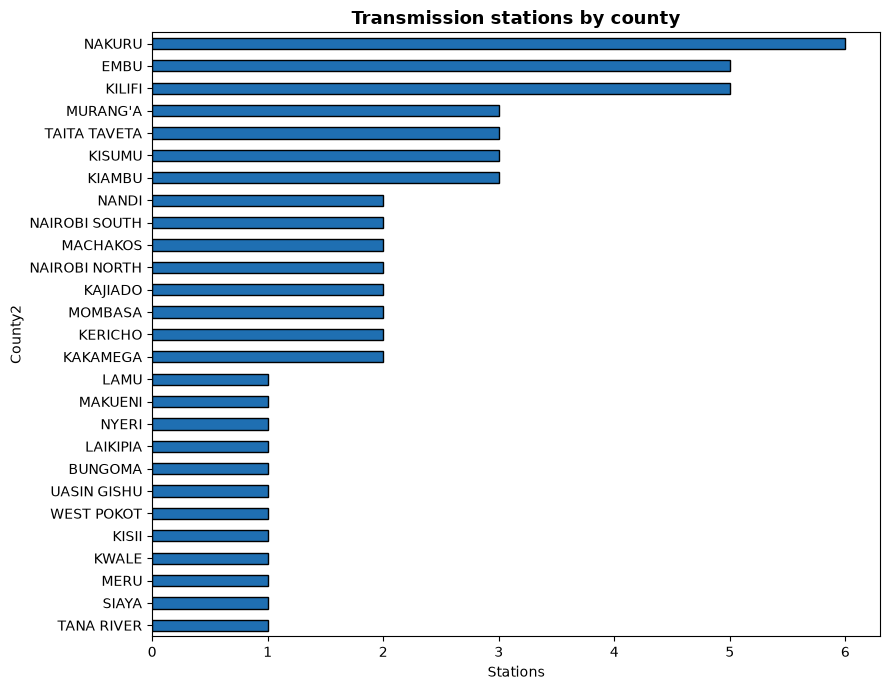

In [39]:
plt.figure(figsize=(9,7))
named["County2"].value_counts().sort_values().plot.barh(color="#1f6fb2", edgecolor="black")
plt.title("Transmission stations by county", fontsize=13, fontweight="bold")
plt.xlabel("Stations"); plt.tight_layout(); plt.show()

Stations are spread across 26 counties plus the two Nairobi utility regions, with no county holding more than a handful: Nakuru has the most (6), followed by Embu and Kilifi (5 each). The registry therefore describes a nationwide network rather than a few hubs. 
*Caveat:* `County2` mixes counties with KPLC regions (Nairobi North/South), and the 27 KETRACO records are excluded because they have no county.

## 11.2 Stations by owner

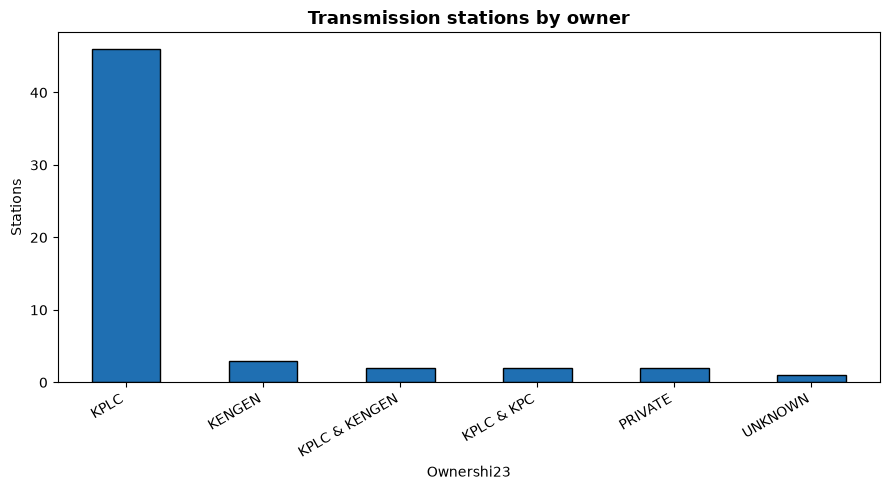

In [40]:
ax = named["Ownershi23"].value_counts().plot.bar(color="#1f6fb2", edgecolor="black", figsize=(9,5))
ax.set_title("Transmission stations by owner", fontsize=13, fontweight="bold")
ax.set_ylabel("Stations"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

KPLC owns 46 of the 56 named stations. The rest are KenGen (3), shared KPLC/KenGen (2), shared KPLC/KPC (2), private (2) and one unknown owner. This is a utility-dominated network, so most data-quality fixes would need to come from KPLC.

## 11.3 Stations by voltage level

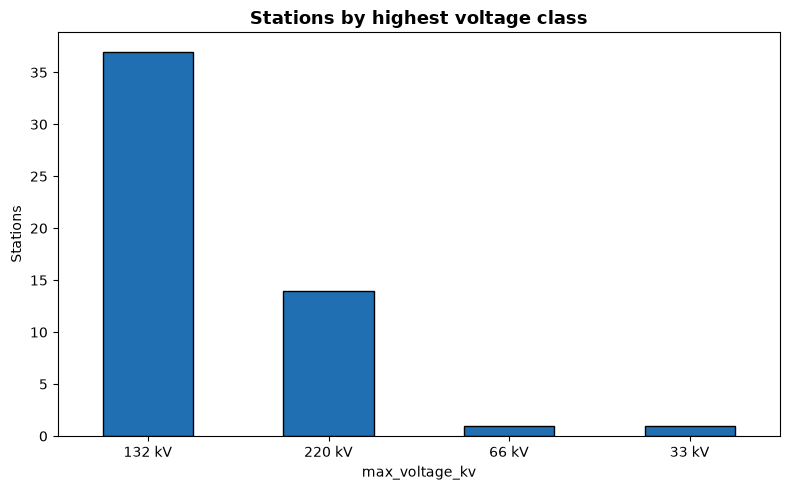

In [41]:
ax = (named["max_voltage_kv"].map({33:"33 kV",66:"66 kV",132:"132 kV",220:"220 kV"})
      .value_counts().plot.bar(color="#1f6fb2", edgecolor="black", figsize=(8,5)))
ax.set_title("Stations by highest voltage class", fontsize=13, fontweight="bold")
ax.set_ylabel("Stations"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

132 kV stations dominate (37), followed by 220 kV (14), with one station each at 66 kV and 33 kV. The backbone is therefore mostly 132 kV, with a smaller 220 kV tier above it. 
*Caveat:* voltage is parsed from free-text names, so 3 stations with no parseable voltage are missing from this chart.

## 11.4 Stations by regional control area

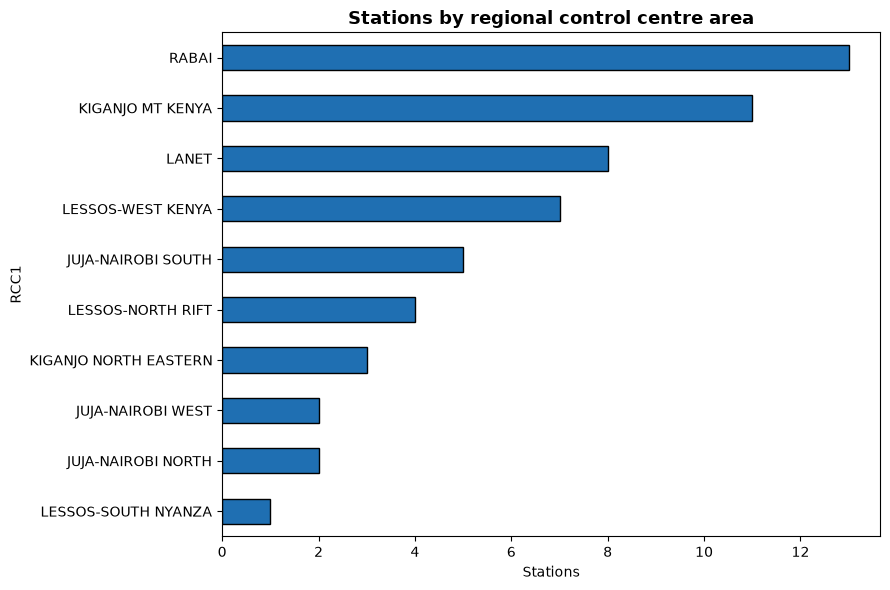

In [42]:
plt.figure(figsize=(9,6))
named["RCC1"].value_counts().sort_values().plot.barh(color="#1f6fb2", edgecolor="black")
plt.title("Stations by regional control centre area", fontsize=13, fontweight="bold")
plt.xlabel("Stations"); plt.tight_layout(); plt.show()

Rabai (13), Kiganjo Mt Kenya (11) and Lanet (8) cover the most stations, so operational responsibility is concentrated in a few control areas. Ten areas are represented in total.


## 11.5 Manned vs unmanned, remote monitoring, access type

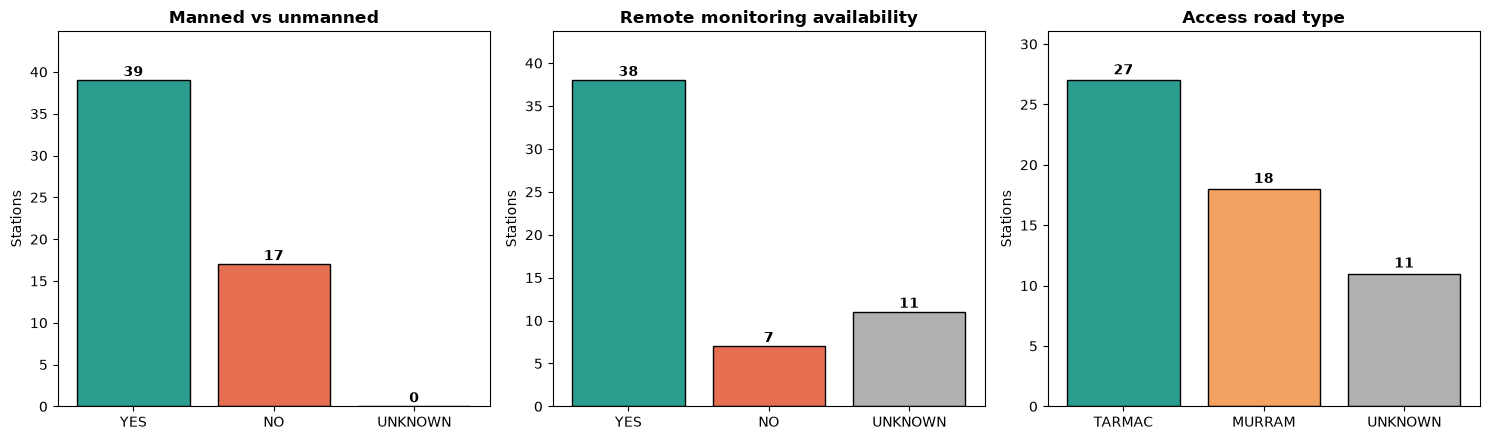

In [43]:
UNKNOWN = "UNKNOWN"
colors = {"YES": "#2a9d8f", "NO": "#e76f51", "TARMAC": "#2a9d8f",
          "MURRAM": "#f4a261", UNKNOWN: "#b0b0b0"}
specs = [("Manned50", "Manned vs unmanned", ["YES", "NO"]),
         ("Remote_T57", "Remote monitoring availability", ["YES", "NO"]),
         ("Type_Acc42", "Access road type", ["TARMAC", "MURRAM"])]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, title, order) in zip(axes, specs):
    counts = (named[col].fillna(UNKNOWN).value_counts()
              .reindex(order + [UNKNOWN], fill_value=0))
    ax.bar(counts.index, counts.values,
           color=[colors[k] for k in counts.index], edgecolor="black")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Stations")
    ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("../reports/figures/operations_overview.png", dpi=150, bbox_inches="tight")
plt.show()

39 of 56 stations are manned, and 38 have remote monitoring. 27 stations sit on tarmac roads and 18 on murram. Murram access may slow maintenance in wet weather. *Caveat:* 11 stations have no remote-monitoring or access data, and `value_counts()` hides them; add an "Unknown" bar.

## 11.6 Communication availability

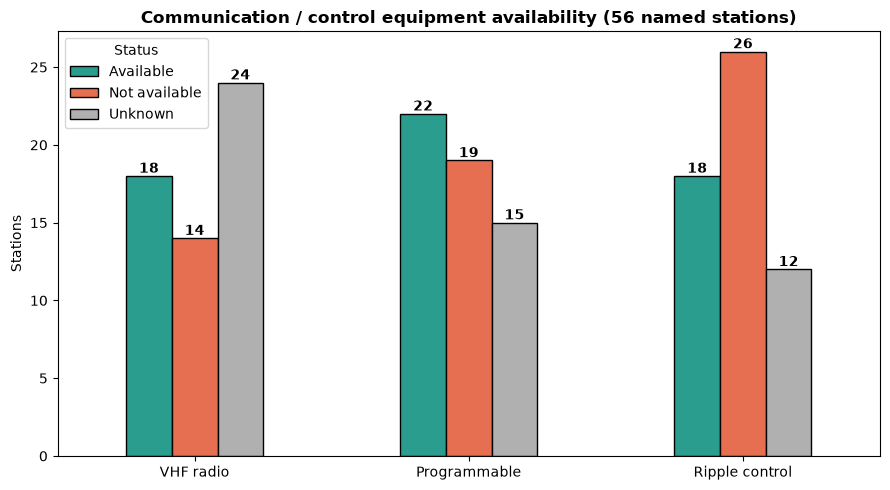

In [44]:
cols = {"VHF_Radi55": "VHF radio", "Programm58": "Programmable", "Ripple_C59": "Ripple control"}
comm = pd.DataFrame({label: named[col].fillna(UNKNOWN).value_counts()
                     for col, label in cols.items()})
comm = comm.reindex(["YES", "NO", UNKNOWN]).fillna(0).astype(int)
comm.index = ["Available", "Not available", "Unknown"]

ax = comm.T.plot.bar(color=["#2a9d8f", "#e76f51", "#b0b0b0"],
                     edgecolor="black", figsize=(9, 5))
for container in ax.containers:
    ax.bar_label(container, fontweight="bold")
ax.set_title("Communication / control equipment availability (56 named stations)",
             fontweight="bold")
ax.set_ylabel("Stations")
ax.legend(title="Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/communication_equipment.png", dpi=150, bbox_inches="tight")
plt.show()

Ripple control is the most often missing (26 stations without it vs 18 with), while VHF radio (18 yes, 14 no) and programmable equipment (22 yes, 19 no) are split almost evenly. Many stations lack these systems, which makes them a candidate focus for investment. *Caveat:* 24, 15 and 12 stations are blank for VHF, programmable and ripple respectively, so the true gap could be larger or smaller. Show these as "Unknown".

## 11.7 Data completeness by source

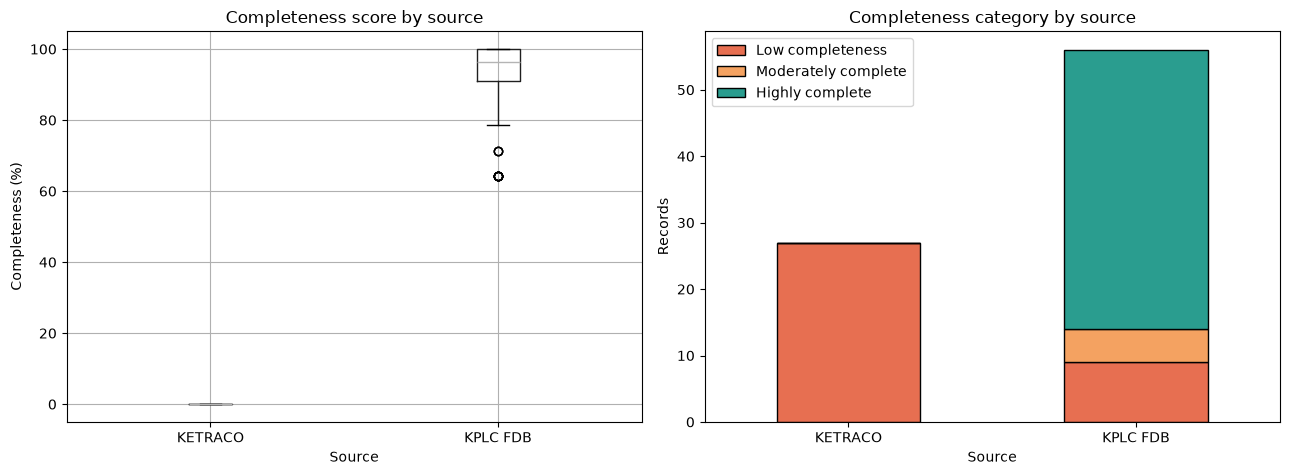

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
df.boxplot(column="completeness_score", by="Source", ax=axes[0])
axes[0].set_title("Completeness score by source"); axes[0].set_ylabel("Completeness (%)")
(df.groupby(["Source","completeness_category"], observed=True).size().unstack(fill_value=0)
   .plot.bar(stacked=True, ax=axes[1], color=["#e76f51","#f4a261","#2a9d8f"], edgecolor="black"))
axes[1].set_title("Completeness category by source"); axes[1].set_ylabel("Records")
axes[1].legend(title=None); plt.xticks(rotation=0); plt.suptitle("")
plt.tight_layout(); plt.savefig("../reports/figures/completeness.png", dpi=150, bbox_inches="tight"); plt.show()

Completeness depends on the source. The 56 KPLC FDB records average 90% complete, while all 27 KETRACO records are 0%, because they carry coordinates only. Overall, 42 records are highly complete, 5 moderately and 36 low. Any analysis must treat the two groups separately.

# 12. Findings and Conclusions

## Dataset structure
- **83 records** total: **56** named stations from `KPLC FDB` + **27** coordinate-only records from `KETRACO`.
- Named stations span **26 counties** (Nairobi region is divided into North and South according to KPLC systems but is one county), **10 regional control centre areas** (largest: Rabai 13, Kiganjo Mt Kenya 11, Lanet 8) and **6 owner categories** (KPLC dominates with 46).
- Voltage classes (highest voltage): **132 kV (37)** and **220 kV (14)** dominate; one 66 kV and one 33 kV station each.

## Data quality
- Missingness is **structural, not random**: Missingness is strongly associated with data source. All 27 KETRACO coordinate-only records lack descriptive attributes, whereas the KPLC FDB records are substantially more complete. Consequently, aggregate missingness rates should be interpreted in the context of source coverage rather than as a uniform data-quality problem.
- Worst variables: `VHF_Radi55` (61% blank), `Programm58` (51%), `Ripple_C59` (47%).
- **7 records** carry the placeholder date `01/01/2000` (treated as unknown and flagged).
- No full-row duplicates; two sites (**KAMBURU**, **LESSOS**) legitimately appear at two voltage levels ~160-260 m apart: naming normalization was needed to detect this.
- Categorical inconsistencies found and fixed: `"0"` vs `"NO"` in `VHF_Radi55`, `"NONE"` owner, case/whitespace drift, `22OKV` typo, non-standard voltages (`3.3`, `15`, `400/200`).

## Operational signals (named stations)
- ~70% are **manned**; ~68% have **remote monitoring**; **VHF radio** is the least available communication channel (18/56).
- Access is split **27 tarmac / 18 murram** (11 unknown).

## Business relevance for an energy data team
- The two-source structure suggests a **merge/enrichment opportunity**: KETRACO coordinates could be spatially joined to other grid data to recover attributes for the 27 unnamed points.
- Communication-equipment gaps, particularly for VHF and ripple-control fields, provide potential inputs for further asset-investment analysis. However, investment prioritization would require additional operational, reliability, cost and asset-condition data.
- The completeness score is a repeatable **data-governance metric** for tracking future improvements of the station registry.